## Multiple Linear Regression

Multiple Linear Regression is an extension of Simple Linear regression as it takes more than one predictor variable to predict the response variable.

It is an important regression algorithm that models the linear relationship between a single dependent continuous variable and more than one independent variable.

It uses two or more independent variables to predict a dependent variable by fitting a best linear relationship.

It has two or more independent variables (X) and one dependent variable (Y), where Y is the value to be predicted. Thus, it is an approach for predicting a quantitative response using multiple features.

### Equation: Y = β0 + β1X1 + β2X2 + β3X3 + … + βnXn + e

where

Y = Dependent variable / Target variable

β0 = Intercept of the regression line

β1, β2, β3, …. βn = Slope of the regression line which tells whether the line is increasing or decreasing

X1, X2, X3, ….Xn = Independent variable / Predictor variable

e = Error

### Problem statement:

Build a Multiple Linear Regression Model to predict sales based on the money spent on TV, Radio, and Newspaper for advertising.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [3]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\regression\Advertising.csv")

In [4]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
df.shape

(200, 4)

In [6]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [7]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


### Plotting correlation heatmap

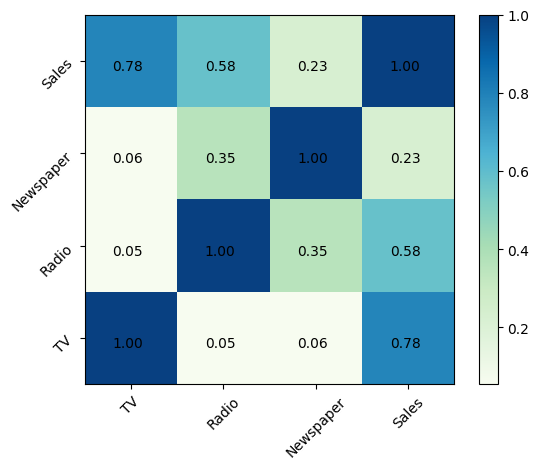

In [51]:
plt.ylim(-.5,3.5) #Without this, the first or last row may sometimes get cut off.
plt.imshow(df.corr(), cmap = plt.cm.GnBu, interpolation = 'nearest', data = True)
#interpolation = nearest, makes each square appear clearly.Without interpolation, colors may become blurred.
plt.colorbar() #showing what each color means.

tick_marks = [i for i in range(len(df.columns))]
plt.xticks(tick_marks, df.columns, rotation = 45)
plt.yticks(tick_marks, df.columns, rotation = 45)

#annotations

for i in range(len(df.columns)):
  for j in range(len(df.columns)):
    text = '%.2f'%(df.corr().iloc[i,j])
    plt.text(i-0.2,j-0.1,text) #The -0.2 and -0.1 are small adjustments to center the text.Without them, the numbers may not sit nicely inside the boxes.



In [39]:
x = df[['TV','Radio','Newspaper']]
y = df['Sales']

In [40]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state = 42)


In [41]:
mlr = LinearRegression()
mlr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
print('intercept:',mlr.intercept_)
print('coefficients:')
list(zip(mlr.coef_))

intercept: 3.051740809019428
coefficients:


[(np.float64(0.04510459634958991),),
 (np.float64(0.1851183066715002),),
 (np.float64(0.0018134090175297541),)]

### Regression Equation: Sales = 3.05 + (0.045 * TV) + (0.185* Radio) + (0.002 * Newspaper) + e

In [43]:
y_pred = mlr.predict(x_test)

print('predicted values for test set: {}'.format(y_pred))

predicted values for test set: [16.36298922 20.7912515  21.58006443 10.49229619 22.06488332 13.01380338
 21.00643569  7.48770971 13.73616094 15.17183991  9.03043544  6.69565172
 14.41194798  8.84738904  9.78081712 12.2362979   8.65790391 16.303416
 10.26495433 18.87027292]


In [44]:
mlr_diff = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred})

In [45]:
mlr_diff.head()

,Actual value,Predicted value
95,16.9,16.362989
15,22.4,20.791252
30,21.4,21.580064
158,7.3,10.492296
128,24.7,22.064883


Simple Linear Regression (1 feature):
- Scatter plot and regression line can be drawn.

Multiple Linear Regression (multiple features):
- A single 2D regression line cannot be drawn because there are multiple input variables.
- Use R², MAE, MSE, RMSE, or Actual vs Predicted comparisons instead.

In [48]:
mlr_diff['error'] = mlr_diff['Actual value'] - mlr_diff['Predicted value']
mlr_diff.head()

,Actual value,Predicted value,error
95,16.9,16.362989,0.537011
15,22.4,20.791252,1.608748
30,21.4,21.580064,-0.180064
158,7.3,10.492296,-3.192296
128,24.7,22.064883,2.635117


Actual Value  : True value from the dataset.

Predicted Value : Value predicted by the model.

Error = Actual Value - Predicted Value

Smaller error indicates better predictions.

In [29]:
from sklearn import metrics

mean_abs_error = metrics.mean_absolute_error(y_test,y_pred)
mean_sqr_error = metrics.mean_squared_error(y_test,y_pred)
root_mean_sqr_error = np.sqrt(metrics.mean_squared_error(y_test,y_pred))

print('R squared: {:.2f}'.format(mlr.score(x_test,y_test)*100))
print("MAE:",mean_abs_error)
print("MSE:",mean_sqr_error)
print("RMSE:",root_mean_sqr_error)

R squared: 90.47
MAE: 1.3694443359949913
MSE: 3.1308020912380488
RMSE: 1.7694072711611786


In [47]:
print(x_test.shape)
print(y_test.shape)

(20, 3)
(20,)
